<a href="https://colab.research.google.com/github/Yash-k10/Machine_vision/blob/main/Practical3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload Reference Road Sign Image


Saving img1.jpg to img1 (2).jpg

Upload Test Image


Saving test_img.jpg to test_img.jpg
Reference Keypoints : 668
Test Keypoints : 1000
Total Matches : 83


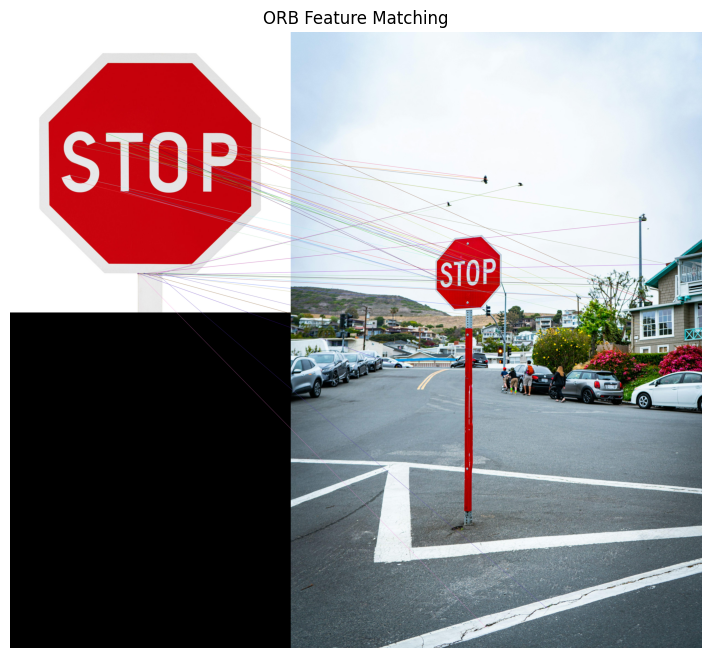


✅ Road Sign Identified Successfully


In [2]:
# ==========================================
# Road Sign Recognition using ORB
# ==========================================

# Install OpenCV
!pip install opencv-python-headless -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload Reference Road Sign Image")
uploaded = files.upload()

ref_path = list(uploaded.keys())[0]

print("\nUpload Test Image")
uploaded = files.upload()

test_path = list(uploaded.keys())[0]

# Read Images
reference = cv2.imread(ref_path)
test = cv2.imread(test_path)

reference_gray = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)
test_gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)

# ----------------------------------------
# ORB Detector
# ----------------------------------------

orb = cv2.ORB_create(nfeatures=1000)

# Detect keypoints and descriptors
kp1, des1 = orb.detectAndCompute(reference_gray, None)
kp2, des2 = orb.detectAndCompute(test_gray, None)

print("Reference Keypoints :", len(kp1))
print("Test Keypoints :", len(kp2))

# ----------------------------------------
# Feature Matching
# ----------------------------------------

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

print("Total Matches :", len(matches))

# Best matches
good_matches = matches[:50]

# ----------------------------------------
# Draw Matches
# ----------------------------------------

matched_image = cv2.drawMatches(
    reference,
    kp1,
    test,
    kp2,
    good_matches,
    None,
    flags=2
)

plt.figure(figsize=(18,8))
plt.imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("ORB Feature Matching")
plt.show()

# ----------------------------------------
# Recognition Decision
# ----------------------------------------

threshold = 20

if len(good_matches) > threshold:
    print("\n✅ Road Sign Identified Successfully")
else:
    print("\n❌ Road Sign Not Found")